<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/note_score_based_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Score-Based Models

參考:
- Stanford CS236: Deep Generative Models I 2023
  - [Lecture 13 - Score Based Models
](https://www.youtube.com/watch?v=8G-OsDs1RLI&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=20)
  - [Syllabus](https://deepgenerativemodels.github.io/syllabus.html)

#### Score-Based Model

*Definition* ***vector field***

$F(x)=\begin{bmatrix}
F_1(x)\\
\vdots\\
F_d(x)
\end{bmatrix};\ \mathbb{R}^d \to \mathbb{R}^d$

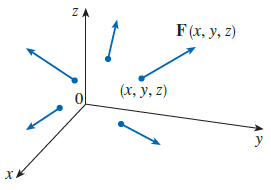

*Definition* ***gradient vector field***

$\nabla f(x)=\begin{bmatrix}
f_{x_1}(x)\\
\vdots\\
f_{x_d}(x)
\end{bmatrix};\ \mathbb{R}^d \to \mathbb{R}^d$

score function: $\nabla_x \log p(x)$
- gradient vector field: $\mathbb{R}^d \to \mathbb{R}^d$



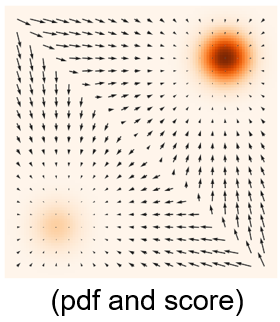

the score function is potentially much easier to work with

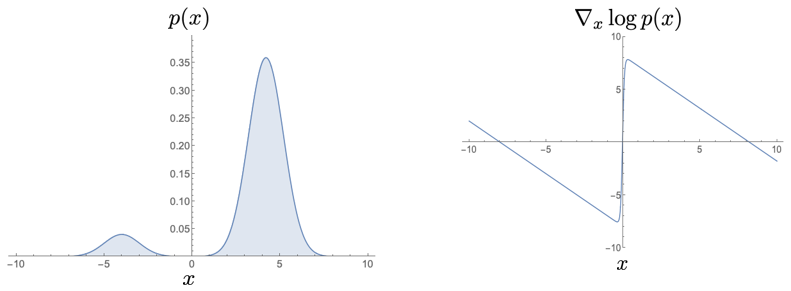

score-based model
- instead of modeling data using the density we're going to model data using the score
- $s_\theta(x): \mathbb{R}^d \to \mathbb{R}^d$

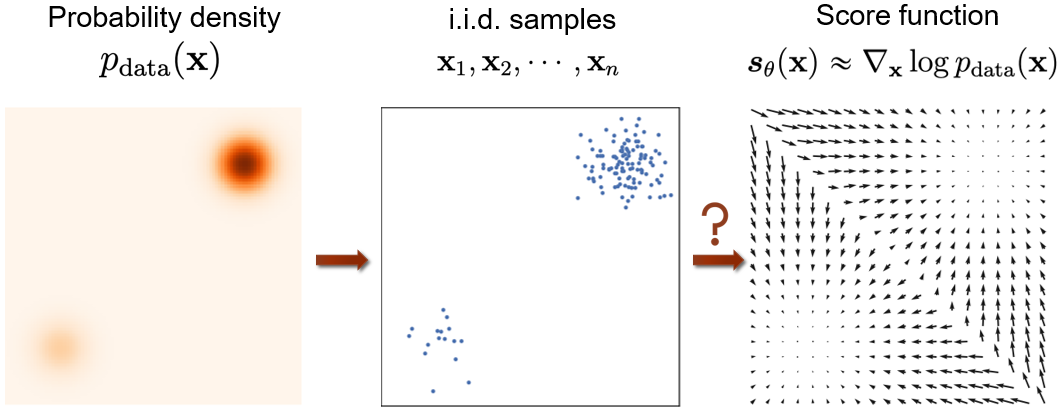

#### Score Matching

How to compare two vector fields of scores?

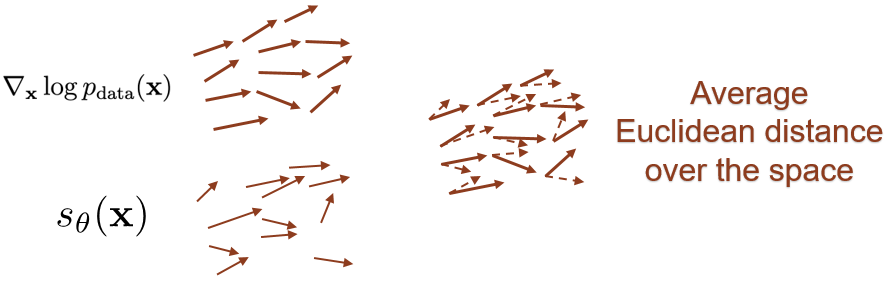

*Definition* ***Fisher divergence*** between $p(x)$ and $q(x)$

$D_F(p,q)=\frac{1}{2}\mathbb{E}_{x \sim p} \| \nabla_x \log p(x) - \nabla_x \log q(x) \|$

objective
- Fisher divergence: $\frac{1}{2}\mathbb{E}_{x \sim p_{\text{data}}} \| \nabla_x \log p_{\text{data}}(x) - s_\theta(x) \|_2^2$
- How to deal with $\nabla_x \log p_{\text{data}}(x)$ given only samples?

score matching
- $\mathbb{E}_{x \sim p_{\text{data}}} \left[ \frac{1}{2}\| s_\theta(x) \|_2^2 + \text{tr} \left( \nabla_x s_\theta(x) \right) \right]$
  - $\nabla_x s_\theta(x)$: Jacobian of $s_\theta(x)$

computing $\nabla_x s_\theta(x)$ is not scalable

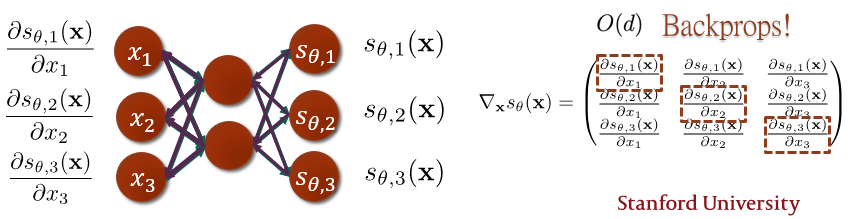

#### Denoising Score Matching

perturbed disttribution
- $q_\sigma(\tilde{x} \mid x)=\mathcal{N}(x;\sigma^2I)$
- $q_\sigma(\tilde{x})=\int p(x) q_\sigma(\tilde{x} \mid x) \text{d}x$

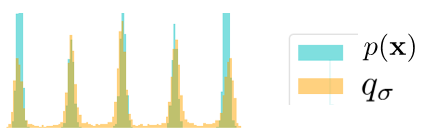

- Score estimation for $\nabla_{\tilde{x}} \log q_\sigma(\tilde{x})$ is easier
- If the noise level is small, this is a good approximation q_\sigma(\tilde{x} \approx p({\tilde{x}}))

*Norm squared identity*

$\| a-b \|_2^2=\| a \|_2^2+\| b \|_2^2-2a^Tb$

$\begin{align*}
&\quad\ \frac{1}{2}\mathbb{E}_{\tilde{x} \sim q_\sigma} \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) - s_\theta(\tilde{x}) \|_2^2 \\
&= \frac{1}{2}\int q_\sigma(\tilde{x}) \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) - s_\theta(\tilde{x}) \|_2^2 \text{d}\tilde{x} \\
&= \frac{1}{2}\int  q_\sigma(\tilde{x}) \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) \|_2^2 \text{d}\tilde{x}+\frac{1}{2}\int q_\sigma(\tilde{x}) \| s_\theta(\tilde{x}) \|_2^2 \text{d}\tilde{x}-\int q_\sigma(\tilde{x}) \nabla_\tilde{x} \log q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
\end{align*}$

- $\frac{1}{2}\mathbb{E}_{x \sim p_{\text{data}}} \| \nabla_x \log p_{\text{data}}(x) - s_\theta(x) \|_2^2$
- $\frac{1}{2}\int p_{\text{data}}(x) \| \nabla_x \log p_{\text{data}}(x) \|_2^2 \text{d}x +\frac{1}{2}\int p_{\text{data}}(x) \| s_\theta(x) \|_2^2 \text{d}x -\int p_{\text{data}}(x) \nabla_x \log p_{\text{data}}(x)^T s_\theta(x) \text{d}x$
- $const. +\frac{1}{2}\int p_{\text{data}}(x) \| s_\theta(x) \|_2^2 \text{d}x -\int p_{\text{data}}(x) \nabla_x \log p_{\text{data}}(x)^T s_\theta(x) \text{d}x$

$\begin{align*}
&\quad -\int q_\sigma(\tilde{x}) \nabla_\tilde{x} \log q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int q_\sigma(\tilde{x}) \frac{1}{q_\sigma(\tilde{x})} \nabla_\tilde{x} q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \nabla_\tilde{x} q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \nabla_\tilde{x} \left( \int p_{\text{data}}(x) q_\sigma(\tilde{x} \mid x)\text{d}x \right)^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \left( \int p_{\text{data}}(x) \nabla_\tilde{x} q_\sigma(\tilde{x} \mid x)\text{d}x \right)^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \left( \int p_{\text{data}}(x) q_\sigma(\tilde{x} \mid x) \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)\text{d}x \right)^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\iint p_{\text{data}}(x) q_\sigma(\tilde{x} \mid x) \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)^T s_\theta(\tilde{x}) \text{d}x \text{d}\tilde{x} \\
&= -\mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)^T s_\theta(\tilde{x}) \right]
\end{align*}$

*Iterated Expectation*

$\mathbb{E}_X(X)=\mathbb{E}_Y\left[ \mathbb{E}_{X \mid Y}(X \mid Y) \right]$

$\begin{align*}
&\quad\ \frac{1}{2}\mathbb{E}_{\tilde{x} \sim q_\sigma} \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) - s_\theta(\tilde{x}) \|_2^2 \\
&= const. +\frac{1}{2}\int q_\sigma(\tilde{x}) \| s_\theta(\tilde{x}) \|_2^2 \text{d}\tilde{x}-\int q_\sigma(\tilde{x}) \nabla_\tilde{x} \log q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= const. +\frac{1}{2} \mathbb{E}_{\tilde{x} \sim q_\sigma} \left[ \| s_\theta(\tilde{x}) \|_2^2 \right]  -\mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)^T s_\theta(\tilde{x}) \right] \\
&= const. +\frac{1}{2} \mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \| s_\theta(\tilde{x})-\nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x) \|_2^2 \right]  -\frac{1}{2}\mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x) \right] \\
&= \frac{1}{2} \mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \| s_\theta(\tilde{x})-\nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x) \|_2^2 \right] +const.
\end{align*}$

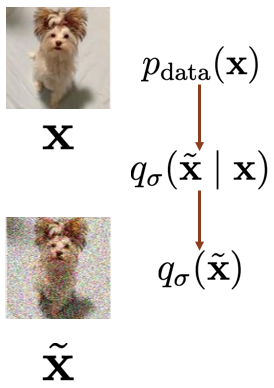